# Preposicao

Pergunta: Como as proposições legislativas abordam os impactos ambientais da inteligência artificial e da infraestrutura digital entre 2023 e 2025?


## Metodologia
O notebook coleta as ementas, limpa os dados, seleciona os termos do tema e classifica as proposições com a API da OpenAI.


## Dependências
Instala as bibliotecas do projeto


In [8]:
%pip install -q requests==2.34.2 pandas==2.3.3 openai==3.13.0 python-dotenv==1.2.3 pydantic==2.13.5 matplotlib==3.10.9


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports
Carrega as bibliotecas do projeto.


In [9]:
import os
from getpass import getpass
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import Markdown, display
from openai import OpenAI
from pydantic import BaseModel
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

## Configuração

Define as variáveis de ambiente

In [10]:
ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
load_dotenv(ROOT / ".env", override=True)
OPENAI_API_KEY_VALUE = os.getenv("OPENAI_API_KEY", "").strip()
if not OPENAI_API_KEY_VALUE:
    OPENAI_API_KEY_VALUE = getpass("OPENAI_API_KEY: ")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini").strip()

OPENAI_PARAMETERS = {"temperature": 0, "max_output_tokens": 500, "store": False}
START, END = "2023-01-01", "2025-12-31"
TYPES = ["PL", "PLP", "PEC", "MPV"]
CAMARA_API_URL = "https://dadosabertos.camara.leg.br/api/v2/proposicoes"
STAGES = ROOT / "outputs"
OPENAI_CLIENT = OpenAI(api_key=OPENAI_API_KEY_VALUE, timeout=60, max_retries=3)

## Coleta
Consulta as proposições na API da Câmara.


In [11]:
CAMARA_SESSION = requests.Session()
CAMARA_SESSION.mount("https://", HTTPAdapter(max_retries=Retry(total=3, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504])))

records = []
pages = 0
start = pd.Timestamp(START)

while start <= pd.Timestamp(END):
    finish = min(start + pd.DateOffset(months=3) - pd.Timedelta(days=1), pd.Timestamp(END))
    params = {
        "siglaTipo": ",".join(TYPES),
        "dataApresentacaoInicio": start.strftime("%Y-%m-%d"),
        "dataApresentacaoFim": finish.strftime("%Y-%m-%d"),
        "itens": 100
    }
    url = requests.Request("GET", CAMARA_API_URL, params=params).prepare().url

    while url:
        camara_response = CAMARA_SESSION.get(url, timeout=60)
        camara_response.raise_for_status()
        page = camara_response.json()
        pages += 1
        records.extend(page["dados"])
        url = next((link["href"] for link in page["links"] if link["rel"] == "next"), None)

    start = finish + pd.Timedelta(days=1)

CAMARA_SESSION.close()
raw = pd.DataFrame(records)
STAGES.joinpath("01_coleta").mkdir(parents=True, exist_ok=True)
raw.to_csv(STAGES / "01_coleta" / "proposicoes_brutas.csv", index=False, encoding="utf-8-sig")

display(pd.Series({
    "Período": f"{START} a {END}",
    "Páginas": pages,
    "Registros recebidos": len(raw)
}, name="Coleta"))

Período                2023-01-01 a 2025-12-31
Páginas                                    181
Registros recebidos                      17516
Name: Coleta, dtype: object

## Limpeza
Prepara os dados e seleciona as ementas relacionadas ao tema.


In [12]:
raw = pd.read_csv(STAGES / "01_coleta" / "proposicoes_brutas.csv")
base = raw[["id", "siglaTipo", "numero", "ano", "dataApresentacao", "ementa", "uri"]].copy()
coletados = len(base)
ausentes = base[["id", "siglaTipo", "dataApresentacao", "ementa"]].isna().any(axis=1).sum()
duplicadas = base["id"].duplicated().sum()
base["date"] = pd.to_datetime(base["dataApresentacao"], errors="coerce")
base["text"] = base["ementa"].fillna("").str.lower()
base = base.dropna(subset=["id", "siglaTipo", "date"])
base = base[base["siglaTipo"].isin(TYPES)]
base = base[base["date"].between(START, END)]
base = base[base["text"].str.strip() != ""]
base = base.drop_duplicates("id")

tecnologia = "inteligência artificial|data center|datacenter|infraestrutura digital|computação em nuvem"
ambiente = "água|energia|carbono|clima|resíduo|ambiental|meio ambiente"
candidates = base[
    base["ementa"].fillna("").str.contains(tecnologia, case=False, regex=True)
    & base["ementa"].fillna("").str.contains(ambiente, case=False, regex=True)
].copy()
candidates["proposal"] = candidates["siglaTipo"] + " " + candidates["numero"].astype(str) + "/" + candidates["ano"].astype(str)

STAGES.joinpath("02_limpeza").mkdir(parents=True, exist_ok=True)
candidates.to_csv(STAGES / "02_limpeza" / "candidatos_gpt.csv", index=False, encoding="utf-8-sig")
display(pd.Series({"Coletados": coletados, "Dados incompletos": int(ausentes), "Duplicatas": int(duplicadas), "Candidatos": len(candidates)}, name="Qualidade"))
display(candidates[["proposal", "ementa"]])


Coletados            17516
Dados incompletos        0
Duplicatas               0
Candidatos               5
Name: Qualidade, dtype: int64

,proposal,ementa
9163,PL 3604/2024,"Altera a Lei nº 12.114, de 9 de dezembro de 20..."
12578,PL 2080/2025,Institui a Política Nacional de Eficiência Ene...
14948,PL 4621/2025,Dispõe sobre a destinação de percentual das re...
16368,PL 6102/2025,Dispõe sobre a obrigatoriedade de identificaçã...
16951,PLP 280/2025,"Altera a Lei Complementar nº 140, de 8 de deze..."


## Classificação
Classifica as ementas e registra as evidências textuais.


In [13]:
class Classification(BaseModel):
    relation: Literal["Direta", "Indireta", "Ausente", "Incerta"]
    themes: list[Literal["Água", "Energia", "Clima e emissões", "Resíduos", "Meio ambiente"]]
    approach: str
    evidence: str

PROMPT = """Leia a ementa e classifique a relação ambiental:
Direta: trata dos impactos ambientais da IA ou da infraestrutura digital.
Indireta: usa tecnologia para proteger o meio ambiente ou associa tecnologia e financiamento ambiental.
Ausente: não apresenta relação ambiental.
Incerta: faltam informações para decidir.
Informe os temas ambientais mencionados e explique a proposta em uma frase.
Em evidence, copie um trecho da ementa que apoie sua resposta.
Use apenas informações da ementa, sem afirmar que a proposta já virou lei ou trouxe resultados."""

print("Modelo OpenAI:", OPENAI_MODEL)
print("Parâmetros:", OPENAI_PARAMETERS)
print("Prompt:", PROMPT)

candidates = pd.read_csv(STAGES / "02_limpeza" / "candidatos_gpt.csv")
answers = []
for row in candidates.itertuples():
    openai_response = OPENAI_CLIENT.responses.parse(
        model=OPENAI_MODEL,
        instructions=PROMPT,
        input=row.ementa,
        text_format=Classification,
        **OPENAI_PARAMETERS
    )
    if openai_response.status != "completed" or openai_response.output_parsed is None:
        raise ValueError(f"Resposta incompleta para {row.proposal}.")
    item = openai_response.output_parsed
    answers.append({
        "id": row.id,
        "relation": item.relation,
        "themes": "; ".join(item.themes),
        "approach": item.approach,
        "evidence": item.evidence,
        "evidence_found": bool(item.evidence.strip()) and item.evidence in row.ementa,
        "model": openai_response.model
    })

results = candidates.merge(pd.DataFrame(answers), on="id", validate="one_to_one")
STAGES.joinpath("03_classificacao").mkdir(parents=True, exist_ok=True)
results.to_csv(STAGES / "03_classificacao" / "classificacoes_gpt.csv", index=False, encoding="utf-8-sig")

Modelo OpenAI: gpt-4.1-mini-2025-04-14
Parâmetros: {'temperature': 0, 'max_output_tokens': 500, 'store': False}
Prompt: Leia a ementa e classifique a relação ambiental:
Direta: trata dos impactos ambientais da IA ou da infraestrutura digital.
Indireta: usa tecnologia para proteger o meio ambiente ou associa tecnologia e financiamento ambiental.
Ausente: não apresenta relação ambiental.
Incerta: faltam informações para decidir.
Informe os temas ambientais mencionados e explique a proposta em uma frase.
Em evidence, copie um trecho da ementa que apoie sua resposta.
Use apenas informações da ementa, sem afirmar que a proposta já virou lei ou trouxe resultados.


## Revisão
Exibe as classificações e sua distribuição.


,proposal,ementa,relation,themes,approach,evidence,evidence_found,uri,model
0,PL 3604/2024,"Altera a Lei nº 12.114, de 9 de dezembro de 20...",Indireta,Clima e emissões; Meio ambiente; Energia,Permite o investimento de recursos do Fundo Na...,permitir o investimento de recursos no desenvo...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
1,PL 2080/2025,Institui a Política Nacional de Eficiência Ene...,Direta,Energia; Meio ambiente,Estabelece uma política nacional para promover...,Institui a Política Nacional de Eficiência Ene...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
2,PL 4621/2025,Dispõe sobre a destinação de percentual das re...,Indireta,Meio ambiente; Energia,A proposta destina parte das receitas da explo...,Dispõe sobre a destinação de percentual das re...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
3,PL 6102/2025,Dispõe sobre a obrigatoriedade de identificaçã...,Ausente,NaN,Regulamenta a identificação de conteúdos produ...,Dispõe sobre a obrigatoriedade de identificaçã...,True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14
4,PLP 280/2025,"Altera a Lei Complementar nº 140, de 8 de deze...",Direta,Energia; Meio ambiente,Define competência para licenciamento ambienta...,"Altera a Lei Complementar nº 140, de 8 de deze...",True,https://dadosabertos.camara.leg.br/api/v2/prop...,gpt-4.1-mini-2025-04-14


,Proposições
Classificação,
Indireta,2
Direta,2
Ausente,1


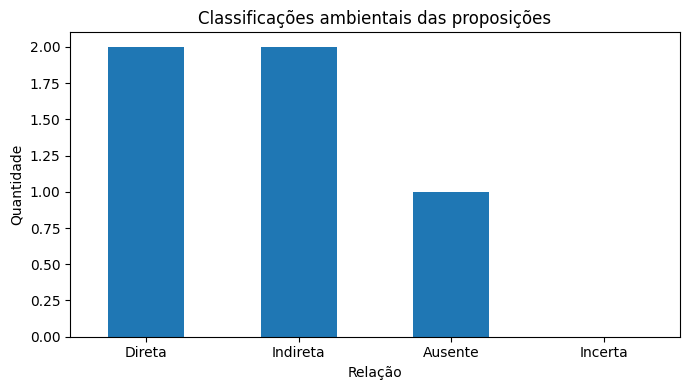

In [14]:
results = pd.read_csv(STAGES / "03_classificacao" / "classificacoes_gpt.csv")
review = results[[
    "proposal", "ementa", "relation", "themes", "approach", "evidence", "evidence_found", "uri", "model"
]]
display(review)
display(results.relation.value_counts().rename_axis("Classificação").to_frame("Proposições"))
STAGES.joinpath("04_revisao").mkdir(parents=True, exist_ok=True)
review.to_csv(STAGES / "04_revisao" / "revisao_resultados.csv", index=False, encoding="utf-8-sig")

counts = results.relation.value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
counts.reindex(["Direta", "Indireta", "Ausente", "Incerta"], fill_value=0).plot.bar(ax=ax, rot=0)
ax.set(title="Classificações ambientais das proposições", xlabel="Relação", ylabel="Quantidade")
fig.tight_layout()
display(fig)
plt.close(fig)